## Purpose
To do sanity checks on the validity of the slice-by-slice altitude determination (from 1D_spherical_slices_over_full img), especially given the weird downwards trend in altitude and the unusually low altitude (only care about longides in [249, 262], the rest should be junk from getting near the edge of the bounding box)

### Main things to try:  
1. triangulation using the top and bottom of the longitude slice at 249 degrees (projected to 245, 250, 250km alt, so go with 250km), and the longitude slice at 261 degrees (projected to a height of 135, 130, 130km alt, so go with 130)
   - identify the lat/lon for the top and bottom of the aurora at each of these longitudes and respective projection heights, back project to az/el, and then get the camera rays for the top and bottom for each site and make sure they intersect, or at least are close to intersecting
   - the key thing with testing multiple longitudes where our 3 different metrics agree on altitude determination is to see that the methods agree
2. Use FSMI as the anchor insted of YKNF
   - CHECKS: consistency of the slice method, making sure there are the same peaks and dips as moving across the images in longitude
3. Run the same pipeline for another timestamp
4. Use an epipolar projection instead
   - choose an (az/el) point along the edge of the YKNF image, build its ray, and "slide" the ray until FSMI's view of the ray lands on FSMI's top edge
   - maybe base upon choosing from one of the agreed upon longitudes from the 1st main thing to try -- that way can compare the predicted altitude from my method vs this other method with epipolar

### Building on Things to Try
1. Debugging the top/bottom triangulation method:
   - METHOD 0: Do a simple check that deg/rad, m/km, lat range, lon range are consistent with the 
   - METHOD 1: Plot each point along the YKNF and FSMI's rays
     - the ray is defined by a fixed (az/el) that i determined to be the top of the aurora at some lon slice
     - projecting the (az,el) to different altitudes gives points along the ray (lat/lon/alt), with the lat/lon changing as we move outwards along the ray
     - this is a good quick check to see where the rays are going in space
   - METHOD 2: Take the points along YKNF's ray (each point is a projection to one of the altitudes i am testing), and project each one down to FSMI's frame
     - plot each of the points with an associated altitude in FSMI's (az,el) view -- this will trace a curve in the round az/el image space of FSMI
     - also plot the exact (az/el) point where i identified the top of the aurora for the same lon slice in FSMI's camera
     - at the right altitude, the one of YKNF's down-projected ray points will match / get pretty dang close to FSMI's (az/el) for the top of the aurora
2. Full top/bot/middle triangulation method
   - Do all of these same things, esp once this method & the 2nd method with downprojectiong YKNF to FSMI makes sense, for the bottom and middle (peak brightness)
   - should get consistent results / altitude determinations at the top/bot/middle for the same longitude slice (even if there is a bit of drift) 
2. Still try epipolar projection idea? (not implemented for 10/5)
   - this may be redudnant with the 2nd method for debugging top/bot triangulation plot 

### General Setup 

#### Imports

In [149]:
import altitude_helper
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)
from altitude_helper import *

# for interpolation
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

from matplotlib.path import Path # for polygon bounding box 

from scipy import signal # for sliding 1D median filter + correlation function for cross correlation
from scipy.optimize import curve_fit # try to fit gaussian to lat_grid, R_intensity_profile

# for the sanity check, top and bottom of the auroral arcs
!pip install pymap3d
from pymap3d import ecef2geodetic
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import gaussian_filter1d

import traceback

!pip install astropy
from astropy.coordinates import EarthLocation, AltAz, SkyCoord
import astropy.units as u

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 4.2 MB/s  0:00:024.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 3.3 MB/s  0:00:003.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 738.7/738.7 kB 4.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astropy]━━━━━━━━━━ 2/3 [astropy]


#### Data Loading

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


#### Helper Functions

In [15]:
# same as "new_get_lon_intensity_slice", just removed the "new" so no confusion
def get_lon_intensity_slice(lat_proj, lon_proj, rgb, # entire (az,el, rgb) for one camera reprojected to h_target
                         reproj_lat_arr_dict, reproj_lon_arr_dict, # reprojected latitude and longitude for the longitude line/sector
                         reproj_left_lat, reproj_left_lon,  # left side of reprojected bounding box
                         reproj_right_lat, reproj_right_lon,  # right side of reprojected bounding box
                         reproj_bottom_lat, reproj_bottom_lon,  # bottom side of reprojected bounding box
                         reproj_top_lat, reproj_top_lon, # top side of reprojected bounding box
                         site_name, time_index, new_h):
    """
    Given projected latitude and longitude arrays and a particular longitude to slice at (put this particular longitude is relative to 100km proj,
    put it into global_lon_arr as a single element array)
    Find the intensities for the latitudes along this longitude slice  (projected up to new_h, common across both cameras).
    Baseline global_lon_arr and global_lat_arr from 200km (og_h), then projected upwards to new_h. 

    Need to put baseline at 200km because want to see broad range of how the fsmi and yknf peak 
    Use 247.95 degrees longitude as baseline. 

    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        rgb = 3D rgb array (output of mod_plot_lat_lon()) (these are the raw rgb values from the skymap, need to be matched to the projected new projected lat/lon
        time_index = for naming purposes when plotting 
        site_name = for naming purposes when plotting
        og_h = 150,000 km the baseline for where we determined the best longitude slices and the best lat/lon box
        new_h = new height we've projected to for the interpolation (what lat_proj and lon_proj were projected to) 

    output:
        R_peak_lat_arr = 1D arr of all the latitudes that the R-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        G_peak_lat_arr = 1D arr of all the latitudes that the G-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        B_peak_lat_arr = 1D arr of all the latitudes that the B-channel had peak altitude for, interpolated over the different longitudes + restricted to (lat_min_box, lat_max_box)
        lon_arr = 1D arr of all the longitudes corresponding in idx to the peak latitude arrays (should be same length as the other 3 returned arrays)
    """

    # just for printing 
    first_lon_key = next(iter(reproj_lon_arr_dict))
    num_lat_points = len(reproj_lon_arr_dict[first_lon_key])
    # print(f"\n====={new_h/1000.0}km PROJECTION=======")
    # print(
    #     f"Total {len(reproj_lon_arr_dict)} longitude(s) in dict: {list(reproj_lon_arr_dict.keys())}\n"
    #     f"Each longitude slice contains {num_lat_points} latitude points to interpolate.\n"
    # )
    
    # separate into R channel
    R = rgb[:,:, 0]
    #R = rgb[:,:, 1]

    # CHANGE: REPROJECT OUTSIDE THIS FUNCTION, SINCE REPROJECTION OF BOUNDING BOX AND SLICE SHOULD ONLY BE DONE WRT TO YKNF, THEN THE SAME BOX AND LINE SHOULD BE USED FOR INTERPOLATION ON BOTH YKNF AND FSMI
    # reproject the latitude slices and the bounding box for each projection --> already looping through all the lon slices here
    # all based on YKNF  
    # reproj_lat_arr_dict, reproj_lon_arr_dict, reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon = altitude_helper.project_lon_slices_and_box(global_lat_arr, global_lon_arr, # these are in degrees
                                                                                                                                                                                                                           #lat_max_box, lat_min_box, lon_max_box, lon_min_box, # also degrees
                                                                                                                                                                                                                           #lat_camera, lon_camera, og_h, new_h)
    # LEAVE THIS WHITESPACE ALONE
    original_lon_arr = reproj_lat_arr_dict.keys() # these keys should be the same as take from reproj_lon_arr_dict, and in degrees
    reproj_lon_slice_arr = reproj_lon_arr_dict.values() # this is array of arrays of longitude corresp. to each longitude of the original slices (should just be 1 value)
    reproj_lat_slice_arr = reproj_lat_arr_dict.values() # this is array of latitude for each longiutde in reproj_lon_slice


    # preallocate
    num_slices = len(original_lon_arr)
    R_peak_lat_arr = np.full(num_slices, np.nan)
    R_lon_arr = np.full(num_slices, np.nan)# longitudes that correspond to the peak latitude 
    #lon_buffer = 5 # no longer needed with the custom rectuangular box around which to interpolate the warped lon slices

    
    # defaults so the return never hits an unbound variable
    reproj_lat_slice = np.array([])
    R_intensity_profile = np.array([])

    for idx, (original_lon,reproj_lat_slice, reproj_lon_slice) in enumerate(zip(original_lon_arr, reproj_lat_slice_arr, reproj_lon_slice_arr)):
        # restrict reproj_lon/lat_slice to only be within the bounding box (don't care outside of the bounding box)
        slice_in_box_mask = (reproj_lat_slice >= np.min(reproj_bottom_lat)) & (reproj_lat_slice <= np.min(reproj_top_lat))
        reproj_lon_slice = reproj_lon_slice[slice_in_box_mask]
        reproj_lat_slice = reproj_lat_slice[slice_in_box_mask]
        

        # print(f"reproj lon slice = reprojected longitude corresponding to the same az/el pair: {reproj_lon_slice}")

        
        # plot the reprojected longitude slice line and the reprojected bounding box
        alpha = 5
        beta = 5
        rgb_adjusted = cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta) # make aurora easier to see on background

        # remove plotting to speed up code
        # altitude_helper.plot_lon_slice_bounding_box(lat_proj, lon_proj, 
        #                                             reproj_lat_slice, reproj_lon_slice, #slice
        #                                             reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon, #bounding box
        #                                             reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon, #bounding box
        #                                             rgb_adjusted, time_index, site_name, new_h, 
        #                                             picket=False) # set picket=False so no zoomed in plotting view

        ## CHANGED SLICE MASK SO ITS PROPERLY CENTERED AND NOT JUST AN ARBITRARY CUTOFF 
        # looks at the max/min of all the points in the reprojected line and draws a box with a 1 degree buffer around them, preventing arbitrary cutoff of the actual projection line based on the origin 5 degree buffer
        #slice_mask = np.abs(lon_proj - original_lon) <= lon_buffer # might need to change this threshold depending on warp in projection

        if reproj_lon_slice.size == 0:
            R_intensity_profile = np.full(0, np.nan)
            continue
        pad = 1.0
        lon_lo = np.nanmin(reproj_lon_slice) - pad
        lon_hi = np.nanmax(reproj_lon_slice) + pad
        lat_lo = np.nanmin(reproj_lat_slice) - pad
        lat_hi = np.nanmax(reproj_lat_slice) + pad
        slice_mask = ((lon_proj >= lon_lo) & (lon_proj <= lon_hi) &
                      (lat_proj >= lat_lo) & (lat_proj <= lat_hi))
        
        
        lon_slice_points = lon_proj[slice_mask]
        lat_slice_points = lat_proj[slice_mask]
        R_slice_values = R[slice_mask] #already flattened 

        # get lat and lon slices over which to interpolate in the right shape 
        flattened_points = np.column_stack((lat_slice_points.flatten(), lon_slice_points.flatten())) # (N,2) pairs of (lat, lon)

        # masks for NaNs in R, G, and B channels separately (basically remove the NaNs and infinite values if there is) --> where the projected lat, lon, or rgb values corresponding to pixel are NaNs
        nan_mask_R = (np.isfinite(flattened_points[:,0]) & np.isfinite(flattened_points[:,1]) & np.isfinite(R_slice_values))
        points_R_clean = flattened_points[nan_mask_R]
        values_R_clean = R_slice_values[nan_mask_R]

        

        # get interpolation locations (these are just the (lat,lon) pairs from the reprojected longitude slices
        interp_locations = np.column_stack((reproj_lat_slice, reproj_lon_slice))

        # lon offsets to evaluate (e.g., -0.2, -0.1, 0.0, +0.1, +0.2 degrees) --> more techncially accurate to use km distance, bc these will not be the same "distance" / tracking the same points on the aurora as projecting up, the aurora spreads out so will be averaging over smaller vertical sector of the aurora
        lon_offsets = np.arange(-0.2, 0.25, 0.1)  # 5 parallel slices
        
        if len(points_R_clean) >= 3 and len(values_R_clean) >= 3:   # minimum for 2D linear interpolation
            # stack all shifted (lat, lon) target evaluation coordinates
            all_shifted_locs = np.vstack([
                np.column_stack((reproj_lat_slice, reproj_lon_slice + d_lon)) 
                for d_lon in lon_offsets
            ])

            # 1 griddata call for all offset paths simultaneously
            all_interp_values = griddata(points_R_clean, values_R_clean, all_shifted_locs, method='linear')

            # reshape into (num_offsets, numlatpoints) and average across offset slices
            reshaped_profiles = all_interp_values.reshape(len(lon_offsets), len(reproj_lat_slice))
            R_intensity_profile = np.nanmean(reshaped_profiles, axis=0)
        else:
            R_intensity_profile = np.full(len(interp_locations), np.nan)  # or 0

        

   # print(f"reproj lat slice arr: {reproj_lat_slice_arr}")
    #lat_grid = list(reproj_lat_arr_dict.values())[0]
    lat_grid = reproj_lat_slice
    # print(f"{site_name}{new_h} lat grid: {yknf_lat_grid}")
    # print(f"{site_name}{new_h} intensity grid: {R_intensity_profile}")
    
    return lat_grid, R_intensity_profile
    

In [16]:
### different types of fit

def fit_polynomial(site, lat_grid, R_intensity_profile, degree=7):
    # clean NaNs and Infinities
    valid_mask = np.isfinite(lat_grid) & np.isfinite(R_intensity_profile)
    x_data = np.array(lat_grid)[valid_mask]
    y_data = np.array(R_intensity_profile)[valid_mask]

    if len(x_data) < degree + 1:
        print(f"Error: Not enough valid points ({len(x_data)}) for degree {degree} fit.")
        return np.nan

    # fit Polynomial
    coefficients = np.polyfit(x_data, y_data, degree)
    poly_function = np.poly1d(coefficients)

    x_fit = np.linspace(np.min(x_data), np.max(x_data), 500)
    y_fit = poly_function(x_fit)

    # # plotting
    # plt.figure(figsize=(8, 5))
    # plt.scatter(x_data, y_data, color='blue', alpha=0.6, label='Raw Data')
    # plt.plot(x_fit, y_fit, color='red', linewidth=2.5, label=f'Degree {degree} Fit')
    # plt.legend()
    # plt.title(f'{site} Degree {degree} Polynomial Fit')
    # plt.xlabel('Latitude (deg)')
    # plt.ylabel('R-Channel Intensity')
    # plt.grid(True, alpha=0.3)
    # plt.show()

    # calculate cirtla points strictly in domain [min(x), max(x)]
    x_min, x_max = np.min(x_data), np.max(x_data)
    derivative = np.polyder(poly_function)
    critical_points = np.roots(derivative)

    # only keep real roots in boundary range
    real_critical_points = critical_points[
        np.isreal(critical_points) & 
        (critical_points.real >= x_min) & 
        (critical_points.real <= x_max)
    ].real

    # include boundary points (local max might occur at data endpoints)
    candidate_x = np.append(real_critical_points, [x_min, x_max])
    candidate_y = poly_function(candidate_x)

    # peak Max Latitude
    max_idx = np.argmax(candidate_y)
    max_latitude = candidate_x[max_idx]
    max_intensity = candidate_y[max_idx]

    return x_fit, y_fit, max_latitude, max_intensity

    
def cross_correlation(yknf_lat_grid, fsmi_lat_grid, yknf_R_intensity_profile, fsmi_R_intensity_profile):
    """
    Computes cross-correlation and latitude shift between YKNF and FSMI intensity profiles.
    """
    # mask nans from both intensities (y vals) 
    valid_mask = np.isfinite(yknf_R_intensity_profile) & np.isfinite(fsmi_R_intensity_profile)
    
    if np.sum(valid_mask) < 3:
        print("Error: Not enough valid points to compute cross-correlation.")
        return np.nan, np.nan, np.nan

    yknf_clean = yknf_R_intensity_profile[valid_mask]
    fsmi_clean = fsmi_R_intensity_profile[valid_mask]
    lat_clean = yknf_lat_grid[valid_mask]

    # lat_step using latitude grid (xval step)
    lat_step = lat_clean[1] - lat_clean[0]

    # mean-subtract signals to eliminate static baseline offsets
    yknf_norm = yknf_clean - np.mean(yknf_clean)
    fsmi_norm = fsmi_clean - np.mean(fsmi_clean)

    # cross-correlation
    correlation = np.correlate(yknf_norm, fsmi_norm, mode='full')
    
    # Normalize correlation coefficient to range [-1, 1]
    norm_factor = np.sqrt(np.sum(yknf_norm**2) * np.sum(fsmi_norm**2))
    if norm_factor > 0:
        correlation = correlation / norm_factor

    # calculate point lag and latitude lag
    max_corr_index = np.argmax(correlation)
    zero_lag_index = len(fsmi_clean) - 1
    point_lag = max_corr_index - zero_lag_index
    
    latitude_lag = point_lag * lat_step
    max_corr_val = correlation[max_corr_index]

    # print(f"Amt of lag bw FSMI and YKNF in latitude: {latitude_lag:.4f}°")
    # print(f"Max correlation value: {max_corr_val:.3f}")

    return latitude_lag, max_corr_val, correlation[zero_lag_index] 



In [17]:
def plot_lon_intensity_slice(site, lat_grid, R_intensity_interp, lon, h):
    """ 
    Given the latitudes and the R channel pixel intensities along some longitude slice for just one site, 
    make a plot showing how the intensity varies across the latitudes for one slice.

    inputs:
        site: string of site name for plot title (YKNF, FSMI)
        lat_grid: array of latitudes we interpolated to in get_intensity_slice for one site (yknf or fsmi)
        R_intensity_interp: array of intensities for each of the latitudes above (len of R intensity = len lat grid)
        lon: the longitude slice for which we stepped along and looked at the brightnesses at diff latitudes
        h: altitude projected to for this longitude slice

    outputs:
        plot
    """
    plt.figure(figsize=(8, 5))
    
    # Plot  intensity profile
    plt.plot(np.array(lat_grid).flatten(), np.array(R_intensity_interp).flatten(), label=site, color='red', marker='o', linestyle='-')
        
    plt.xlabel("Latitude (deg)")
    plt.ylabel(f"R-channel intensity")
    plt.title(f"{site} {h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_lon_intensity_slices(yknf_lat_grid, yknf_R_intensity_interp, 
                        fsmi_lat_grid, fsmi_R_intensity_interp,
                        lon, h, bsub=False):
    """ 
    Given the latitudes and the R channel pixel intensities along some longitude slice for both yknf and fsmi, 
    make a plot showing how the intensity varies across the latitudes for each of the fsmi and yknf slices

    inputs:
        yknf_lat_grid: array of latitudes we interpolated to in get_intensity_slice for yknf
        yknf_R_intensity_interp: array of intensities for each of the latitudes above (len of R intensity = len lat grid)
        fsmi_lat_grid: equiv.
        fsmi_R_intensity_interp: equiv.
        lon: the longitude slice for which we stepped along and looked at the brightnesses at diff latitudes
        h: altitude projected to for this longitude slice

    outputs:
        plot
    """
    plt.figure(figsize=(8, 5))
    
    # Plot YKNF intensity profile
    plt.plot(np.array(yknf_lat_grid).flatten(), np.array(yknf_R_intensity_interp).flatten(), label='YKNF', color='red', marker='o', linestyle='-')
    
    # Plot FSMI intensity profile
    plt.plot(np.array(fsmi_lat_grid).flatten(), np.array(fsmi_R_intensity_interp).flatten(), label='FSMI', color='blue', marker='x', linestyle='--')
    
    plt.xlabel("Latitude (deg)")
    plt.ylabel("R-channel intensity")
    if bsub:
        plt.title(f"BSUB {h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    else:
        plt.title(f"{h/1000.0}km: R-channel intensity vs Latitude at longitude {lon:.2f}°")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    

In [19]:
def plot_fit_data(yknf_lat_grid, yknf_R_intensity_interp,
                  fsmi_lat_grid, fsmi_R_intensity_interp,
                  lon, h, latitude_lag, max_corr_val):
    
    # flatten grid data 
    yknf_lat_flat = np.array(yknf_lat_grid).flatten()
    yknf_int_flat = np.array(yknf_R_intensity_interp).flatten()
    fsmi_lat_flat = np.array(fsmi_lat_grid).flatten()
    fsmi_int_flat = np.array(fsmi_R_intensity_interp).flatten()

    # pure data maximums
    yknf_intensity_max = np.max(yknf_int_flat)
    yknf_lat_max = yknf_lat_flat[np.argmax(yknf_int_flat)]

    fsmi_intensity_max = np.max(fsmi_int_flat)
    fsmi_lat_max = fsmi_lat_flat[np.argmax(fsmi_int_flat)]
    
    plt.figure(figsize=(10, 6))

    # calculate polynomial fits
    yknf_x_fit, yknf_y_fit, yknf_max_latitude_poly, yknf_max_intensity_poly = fit_polynomial("YKNF", yknf_lat_grid, yknf_R_intensity_interp, degree=7)
    fsmi_x_fit, fsmi_y_fit, fsmi_max_latitude_poly, fsmi_max_intensity_poly = fit_polynomial("FSMI", fsmi_lat_grid, fsmi_R_intensity_interp, degree=7)
    
    # scatter raw points
    plt.scatter(yknf_lat_flat, yknf_int_flat, color='red', alpha=0.3, marker='o', label='YKNF Data')
    plt.scatter(fsmi_lat_flat, fsmi_int_flat, color='blue', alpha=0.3, marker='o', label='FSMI Data')
    
    # fit lines
    plt.plot(yknf_x_fit, yknf_y_fit, label="YKNF poly fit", color='red')
    plt.plot(fsmi_x_fit, fsmi_y_fit, label="FSMI poly fit", color='blue')

    # maximum markers
    plt.scatter(yknf_lat_max, yknf_intensity_max, color='red', marker='X', label="YKNF data max", s=150)
    plt.scatter(yknf_max_latitude_poly, yknf_max_intensity_poly, color='red', marker='^', label="YKNF poly max", s=150)
    
    plt.scatter(fsmi_lat_max, fsmi_intensity_max, color='blue', marker='X', label="FSMI data max", s=150)
    plt.scatter(fsmi_max_latitude_poly, fsmi_max_intensity_poly, color='blue', marker='^', label="FSMI poly max", s=150)

    # ------------------ CROSS CORR LAG VISUALIZATION ------------------
    if np.isfinite(latitude_lag):
        # Anchor the shift starting at the FSMI peak latitude
        x_start = fsmi_max_latitude_poly
        x_end = fsmi_max_latitude_poly + latitude_lag
        
        # Place arrow slightly above the maximum intensity
        peak_y = max(yknf_max_intensity_poly, fsmi_max_intensity_poly) * 1.08
        
        # shaded region from peak of fsmi polynomial fit to a length of latitude equal to latitude_lag 
        plt.axvspan(min(x_start, x_end), max(x_start, x_end), color='purple', alpha=0.15, label='CC Lag')
    
        # 2. arrow for direction + mag of lag 
        plt.annotate(
            '', 
            xy=(x_end, peak_y), 
            xytext=(x_start, peak_y),
            arrowprops=dict(arrowstyle="<->", color="purple", lw=2)
        )
    
        # text label
        plt.text(
            (x_start + x_end) / 2, peak_y * 1.02, 
            f"Lag: {latitude_lag:+.3f}°", 
            fontsize=9, fontweight='bold', color='purple', ha='center'
        )
    # ------------------------------------------------------------------------

    plt.xlabel("Latitude (deg)")
    plt.ylabel("R-channel intensity")
    plt.title(f"{h/1000.0}km - YKNF vs FSMI poly fits & CC Lag - lon{lon:.2f}")
    plt.legend(fontsize='small', bbox_to_anchor=(1.02, 1.0), loc='upper right', borderaxespad=0)
    plt.grid(True)
    plt.tight_layout(rect=[0, 0, 0.85, 1.0])
    plt.show()

### Common Parameters and Variables

In [68]:
#================== SET UP VALUES ====================#
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]


#--------get rgb values for yknf and fsmi for plotting-----------#
time_index = 251
R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1) # shape: (x, y, 3)

R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1) # shape: (x, y, 3)

# contrast adjustment: alpha=contrast, beta=brightness
alpha = 5
beta = 5
rgb_yknf = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)
rgb_fsmi = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta)




# change lat_step from 1.0 to 0.05 
lat_step = 0.05 
lon_step = 1.0

h_target_arr = [130000, 135000, 140000, 145000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000, 200000, 205000, 210000, 215000, 220000, 225000, 230000, 235000, 240000, 245000, 250000, 255000, 260000, 265000, 270000, 275000, 280000, 285000, 290000, 295000, 300000, 305000, 310000, 315000,320000,325000, 330000, 335000, 340000, 345000, 350000]

H_REF = 240000
lat_box_min = 59.5 # lowered bc looked like fsmi getting cut off
lat_box_max = 70
lon_box_min = 240
lon_box_max = 268

global_lat_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
global_lon_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

### Sanity Check 1: Top/Bot Triangulation
The longitude at 250 deg is actually the line in longitude projected up to 250km, so need to get the exact lat/lon points for the "lon line" and then pick out the true (lon,lat) where you get the edge of the aurora, need to plot the actual curved line to visualize.  

Note: going off of the chart from the extended range of altitude testing (50km - 380km)  

Steps:
1. plot the projected 250deg lon line (based in 240km proj from YKNF's base) and the projected YKNF and FSMI (independently projected based on their own camera) to pull out the approximate (lat, lon) where we get the top edge of the aurora and the bottom edge of the aurora along the slice
2. Back project using the YKNF and FSMI cameras respectively to get the az/el corresponding to the point of the top and bottom of the edges
3. Create rays from the az/el of each of the top and bottom edges of the auroras, and check to see how much they are intersecting 

In [182]:
def get_ecef(lat, lon, alt_km):
    """Convert Lat, Lon, Alt (km) to ECEF XYZ (meters)."""
    loc = EarthLocation.from_geodetic(lon=lon*u.deg, lat=lat*u.deg, height=alt_km*u.km)
    return np.array([loc.x.value, loc.y.value, loc.z.value])


def get_unit_ray(camera_ecef, target_lat, target_lon_360, proj_alt_km):
    """
    Converts target (lat, lon [0-360 E], alt_km) into an ECEF unit ray vector.
    """
    target_loc = EarthLocation.from_geodetic(
        lat=target_lat * u.deg,
        lon=target_lon_360 * u.deg,  # Astropy accepts 0-360 deg directly
        height=proj_alt_km * u.km
    )
    target_ecef = np.array([target_loc.x.value, target_loc.y.value, target_loc.z.value])
    
    ray_vec = target_ecef - camera_ecef
    return ray_vec / np.linalg.norm(ray_vec)


def closest_approach(C1, d1, C2, d2):
    """
    Calculates closest distance and midpoint between two 3D lines.
    C1 = ECEF coords for camera 1
    d1 = ray unit direction (ECEF for aurora point), returned by get_unit_ray()
    
    """
    w0 = C1 - C2
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    
    denom = a * c - b**2
    if abs(denom) < 1e-8:
        return None, np.nan  # parallel rays
        
    s = (b * e - c * d) / denom
    t = (a * e - b * d) / denom
    
    P1 = C1 + s * d1
    P2 = C2 + t * d2
    miss_distance_km = np.linalg.norm(P1 - P2) / 1000.0
    midpoint_ecef = (P1 + P2) / 2.0
    
    return midpoint_ecef, miss_distance_km

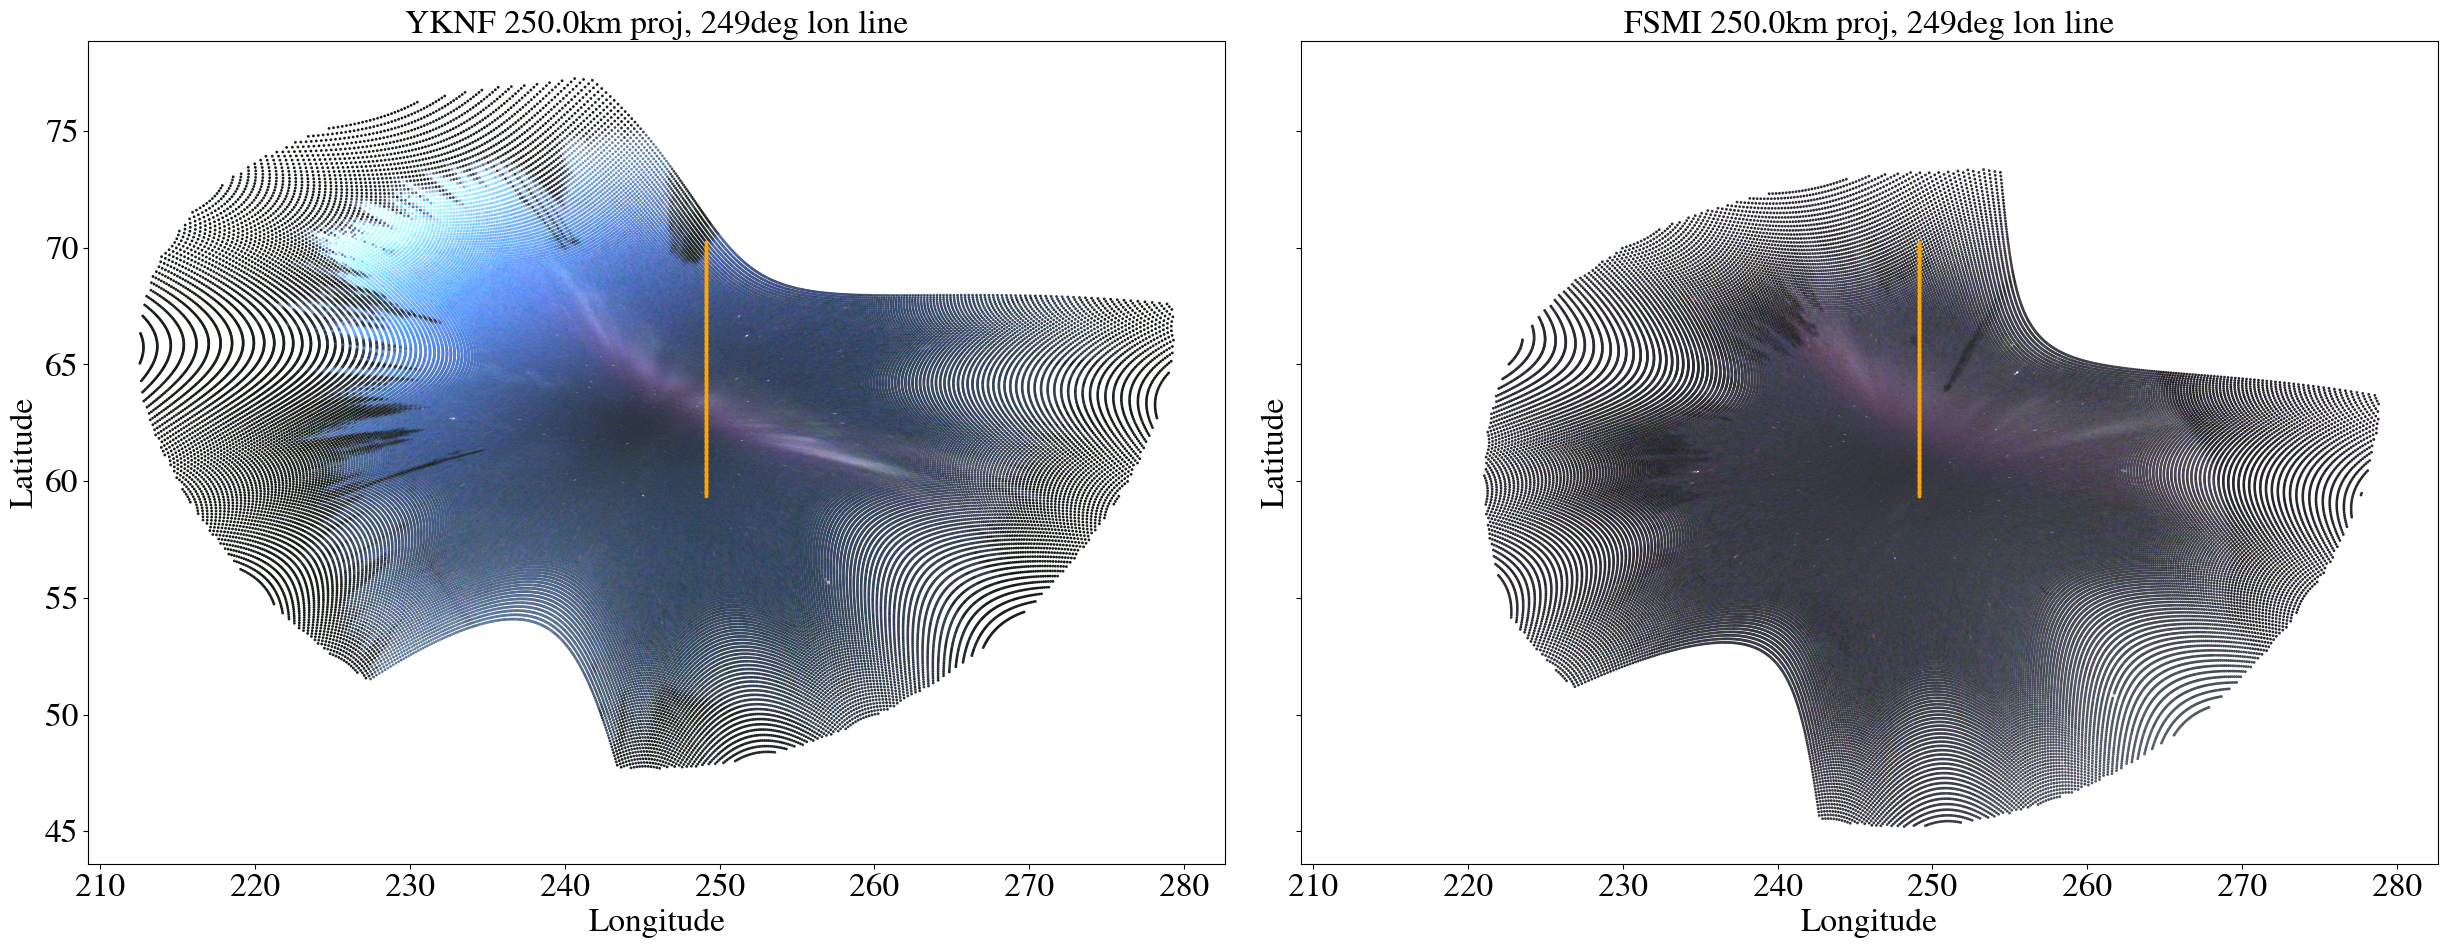

In [126]:
#======== lon: 250deg, alt: 250km???==========#

#------------------------------------INitial Plotting---------------------------------------#

# get the lon slice from baseline 240km projection
H_REF = 240000
new_h = 250000
lon_ref = 249

lat_step = 0.05

# get the straight lon line in 240km projection 
yknf_lon_line_ref = np.full_like(global_lat_arr, lon_ref)
yknf_lat_line_ref = global_lat_arr

# get the azimuth and elevation of each point in the 240km lon line
yknf_lat_line_proj_az, yknf_lon_line_proj_el = altitude_helper.reverse_project_lat_lon(
    yknf_lat_line_ref, yknf_lon_line_ref, lat_cam_yknf, lon_cam_yknf, H_REF
)

# project the az/el of the lon line up to target altitude 
yknf_lat_line_proj, yknf_lon_line_proj= altitude_helper.new_spherical_project_lat_lon(
    yknf_lat_line_proj_az, yknf_lon_line_proj_el, lat_cam_yknf, lon_cam_yknf, new_h
)

# project the background pixels for yknf and fmsi up to 250km as well 
yknf_lat_proj, yknf_lon_proj = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, new_h
)
fsmi_lat_proj, fsmi_lon_proj = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, new_h
)

# side by side plot of the yknf and fsmi cameras, targetting the 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 10), sharex=True, sharey=True)
ax1.scatter(yknf_lon_proj, yknf_lat_proj, c=rgb_yknf.reshape(-1, 3)/255.0, s=1, alpha=1)
ax1.scatter(yknf_lon_line_proj, yknf_lat_line_proj, color='orange', s=3, zorder=2)
ax1.set_title(f'YKNF {new_h/1000.0}km proj, {lon_ref}deg lon line')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

ax2.scatter(fsmi_lon_proj, fsmi_lat_proj, c=rgb_fsmi.reshape(-1, 3)/255.0, s=1, alpha=1)
ax2.scatter(yknf_lon_line_proj, yknf_lat_line_proj, c='orange', s=3, zorder=2)
ax2.set_title(f'FSMI {new_h/1000.0}km proj, {lon_ref}deg lon line')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()


In [151]:
#--------------------------------Identify the top and bottom of lon line in FSMI and YKNF--------------------------------#
matplotlib.use('TkAgg')
# YKNF:interpolate brightnesses to the yknf projected lon line
lon_offsets = np.arange(-0.2, 0.25, 0.1)
flattened_points_yknf = np.column_stack((yknf_lat_proj.ravel(), yknf_lon_proj.ravel()))
R_slice_values_yknf = rgb_yknf.reshape(-1, 3)[:, 0]
good_yknf = np.isfinite(flattened_points_yknf).all(axis=1) & np.isfinite(R_slice_values_yknf)
print("good pixels:", good_yknf.sum(), "/", good_yknf.size)
R_intensity_profile_yknf = np.full(len(yknf_lat_line_proj), np.nan)
if good_yknf.sum() >= 3:
    try:
        interp = LinearNDInterpolator(flattened_points_yknf[good_yknf], R_slice_values_yknf[good_yknf])  # triangulate once
        shifted = np.stack([interp(np.column_stack((yknf_lat_line_proj, yknf_lon_line_proj + d))) for d in lon_offsets])                                    # (n_offsets, n_lat)
        n_valid = np.isfinite(shifted).sum(axis=0)
        R_intensity_profile_yknf = np.where(n_valid >= 3, np.nansum(shifted, axis=0) / np.maximum(n_valid, 1), np.nan)
    except Exception:
        traceback.print_exc()
        pass

# FSMI:interpolate brightnesses to the yknf projected lon line
flattened_points_fsmi = np.column_stack((fsmi_lat_proj.ravel(), fsmi_lon_proj.ravel()))
R_slice_values_fsmi = rgb_fsmi.reshape(-1, 3)[:, 0]
good_fsmi = np.isfinite(flattened_points_fsmi).all(axis=1) & np.isfinite(R_slice_values_fsmi)
print("good pixels:", good_fsmi.sum(), "/", good_fsmi.size)
R_intensity_profile_fsmi = np.full(len(yknf_lat_line_proj), np.nan) # using the same lat line from YKNF's camera
if good_fsmi.sum() >= 3:
    try:
        interp = LinearNDInterpolator(flattened_points_fsmi[good_fsmi], R_slice_values_fsmi[good_fsmi])  # triangulate once
        shifted = np.stack([interp(np.column_stack((yknf_lat_line_proj, yknf_lon_line_proj + d))) for d in lon_offsets]) # using the same lat line from YKNF's camera                                   # (n_offsets, n_lat)
        n_valid = np.isfinite(shifted).sum(axis=0)
        R_intensity_profile_fsmi = np.where(n_valid >= 3, np.nansum(shifted, axis=0) / np.maximum(n_valid, 1), np.nan)
    except Exception:
        traceback.print_exc()
        pass

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, (lat, I, name) in zip(axes, [(yknf_lat_line_proj, R_intensity_profile_yknf, "YKNF"),
                                     (yknf_lat_line_proj, R_intensity_profile_fsmi, "FSMI")]):
    ax.plot(lat, I)

    # max and min of the peak along the lon line, hand picked from code below 
    yknf_hand_max = np.float64(64.21241374005996)
    yknf_hand_min = np.float64(62.282534571309654)
    fsmi_hand_max = np.float64(64.48963395214564)
    fsmi_hand_min = np.float64(61.89869120072948)
    
    if name == "YKNF":
        ax.axvline(x=yknf_hand_max, color='red', linestyle='--', linewidth=1.5, label=f'Eyeball Max Lat: {yknf_hand_max:.2f}')
        ax.axvline(x=yknf_hand_min, color='red', linestyle='--', linewidth=1.5, label=f'Eyeball Min Lat: {yknf_hand_min:.2f}')
        ax.legend()
        
    if name == "FSMI":
        ax.axvline(x=fsmi_hand_max, color='red', linestyle='--', linewidth=1.5, label=f'Eyeball Max Lat: {fsmi_hand_max:.2f}')
        ax.axvline(x=fsmi_hand_min, color='red', linestyle='--', linewidth=1.5, label=f'Eyeball Min Lat: {fsmi_hand_min:.2f}')
        ax.legend() 


    
    ax.set_title(f"{name}, lon {lon_ref}, {new_h/1000:.0f} km")
    ax.set_ylabel("R intensity")
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.6)
    ax.grid(which="minor", alpha=0.25)
axes[-1].set_xlabel("latitude")
plt.tight_layout(); plt.show()


good pixels: 214705 / 265440
good pixels: 212412 / 265440


In [167]:
# get the closest latitude in the actual longitude line we are looking at  --> use these values to construct the cam rays 
yknf_top_idx = np.abs(yknf_lat_line_proj - yknf_hand_max).argmin()
yknf_top_closest_lat = yknf_lat_line_proj[yknf_top_idx]
yknf_top_closest_lon = yknf_lon_line_proj[yknf_top_idx]

yknf_bot_idx = np.abs(yknf_lat_line_proj - yknf_hand_min).argmin()
yknf_bot_closest_lat = yknf_lat_line_proj[yknf_bot_idx]
yknf_bot_closest_lon = yknf_lon_line_proj[yknf_bot_idx]

fsmi_top_idx = np.abs(yknf_lat_line_proj - fsmi_hand_max).argmin()
fsmi_top_closest_lat = yknf_lat_line_proj[fsmi_top_idx]
fsmi_top_closest_lon = yknf_lon_line_proj[fsmi_top_idx]


fsmi_bot_idx = np.abs(yknf_lat_line_proj - fsmi_hand_min).argmin()
fsmi_bot_closest_lat = yknf_lat_line_proj[fsmi_bot_idx]
fsmi_bot_closest_lon = yknf_lon_line_proj[fsmi_bot_idx]


# all still relatively close to the handpicked latitudes, good 
print(yknf_top_closest_lat)  
print(yknf_bot_closest_lat)
print(fsmi_top_closest_lat)  
print(fsmi_bot_closest_lat)

64.21241292350089
62.28965968214583
64.47197313585939
61.87382993783584


In [152]:
#-------------------- Manually Picking out top and bottom of the arc in YKNF and FSMI------------------#
matplotlib.use('TkAgg')  

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharex=True, sharey=True)
for ax, (lon_p, lat_p, rgb, name) in zip(axes, [(yknf_lon_proj, yknf_lat_proj, rgb_yknf, "YKNF"),
                                                (fsmi_lon_proj, fsmi_lat_proj, rgb_fsmi, "FSMI")]):
    img = np.clip(rgb.reshape(-1, 3) / 255.0 * 3.0, 0, 1)      # same stretch for both
    ax.scatter(lon_p, lat_p, c=img, s=12, marker="s", linewidths=0)
    ax.axvline(249, color="orange", lw=0.8)
    ax.set_xlim(245, 253); ax.set_ylim(60, 67); ax.set_title(name)
    ax.minorticks_on(); ax.grid(alpha=0.3)
plt.tight_layout()
pts = plt.ginput(4, timeout=0)   # click YKNF bottom, YKNF top, FSMI bottom, FSMI top
print(pts)
plt.close('all')

# # Picked points at the end of purple if that existed, else picked points at a harsher boundary -- tried to click along the orange line
# # YKNF TOP
# (np.float64(248.99887928975784), np.float64(64.21241374005996))

# # YKNF BOT
# (np.float64(248.98777054600487), np.float64(62.282534571309654))
 
# # FSMI TOP
# (np.float64(248.98874371824408), np.float64(64.48963395214564))
 
# # FSMI BOT 
# (np.float64(248.98874371824408), np.float64(61.89869120072948))

[]


In [184]:
#---------------------------- Converting lat/lon of top and bottom to camera rays-------------------------------#

# convert to ECEF
x_pt_yknf, y_pt_yknf, z_pt_yknf = get_ecef(yknf_top_closest_lat, yknf_top_closest_lon, new_h/1000.0)
x_pt_fsmi, y_pt_fsmi, z_pt_fsmi = get_ecef(fsmi_top_closest_lat, fsmi_top_closest_lon, new_h/1000.0)
x_cam_yknf, y_cam_yknf, z_cam_yknf = get_ecef(lat_cam_yknf, lon_cam_yknf, 0.2)
x_cam_fsmi, y_cam_fsmi, z_cam_fsmi = get_ecef(lat_cam_fsmi, lon_cam_fsmi, 0.2)

C_yknf = np.array([x_cam_yknf, y_cam_yknf, z_cam_yknf])
C_fsmi = np.array([x_cam_fsmi, y_cam_fsmi, z_cam_fsmi])
d_yknf = get_unit_ray(C_yknf, yknf_hand_max, lon_ref, new_h/1000.0)
d_fsmi = get_unit_ray(C_fsmi, fsmi_hand_max, lon_ref, new_h/1000.0)

midpoint_ecef, miss_dist_km = closest_approach(C_yknf, d_yknf, C_fsmi, d_fsmi)
intersection_loc = EarthLocation.from_geocentric(
    x=midpoint_ecef[0]*u.m, # safely convert to meters using astropy 
    y=midpoint_ecef[1]*u.m,
    z=midpoint_ecef[2]*u.m
)

# force returned longitude into 0-360 range
res_lon_360 = intersection_loc.lon.to(u.deg).value % 360

print(f"miss distance: {miss_dist_km:.2f} km") # how far apart the closest points on the 2 rays are
print(f"triangulated pt: Lat={intersection_loc.lat.value:.4f}°, lon={res_lon_360:.4f}°, alt={intersection_loc.height.to(u.km).value:.2f} km") # midpoint of the 2 closest points on the camera rays 

miss distance: 0.01 km
triangulated pt: Lat=60.0955°, lon=248.8523°, alt=-6355.50 km


### Sanity Check 2: FSMI Anchor

In [36]:
n_alts = len(h_target_arr)
n_lons = len(global_lon_arr)

# 2d arrays for storing cross corr, raw peak diff, and poly fit peak diff
zero_lag_matrix = np.full((n_alts, n_lons), np.nan)
lat_lag_matrix = np.full((n_alts, n_lons), np.nan)
raw_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)
poly_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)

for alt_idx, h_target in enumerate(h_target_arr):
    print(f"[{alt_idx+1}/{n_alts}] Processing altitude: {h_target/1000:.1f} km")

    # Projection updates -- project everything wrt to FSMI instead of YKNF!
    yknf_lat_proj, yknf_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, h_target
    )
    fsmi_lat_proj, fsmi_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, h_target
    )

    if H_REF != h_target:
        (
            reproj_lat_dict, reproj_lon_dict,
            reproj_left_lat, reproj_left_lon,
            reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon,
            reproj_top_lat, reproj_top_lon,
        ) = altitude_helper.project_lon_slices_and_box(
            global_lat_arr, global_lon_arr,
            lat_box_max, lat_box_min, lon_box_max, lon_box_min,
            lat_cam_fsmi, lon_cam_fsmi, H_REF, h_target # change to project wrt to FSMI's cam
        )
    else:
        reproj_lat_dict = {lon: np.array(global_lat_arr) for lon in global_lon_arr}
        reproj_lon_dict = {lon: np.full_like(global_lat_arr, lon) for lon in global_lon_arr}
        lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
        lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)
        reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_min)
        reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_max)
        reproj_bottom_lat, reproj_bottom_lon = np.full_like(lon_box_arr, fill_value=lat_box_min), lon_box_arr
        reproj_top_lat, reproj_top_lon = np.full_like(lon_box_arr, fill_value=lat_box_max), lon_box_arr

    # Slice loop
    for lon_idx, current_lon in enumerate(global_lon_arr):
        yknf_lat_slice, yknf_R_interp = get_lon_intensity_slice(
            yknf_lat_proj, yknf_lon_proj, rgb_yknf,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "YKNF", time_index, h_target
        )

        fsmi_lat_slice, fsmi_R_interp = get_lon_intensity_slice(
            fsmi_lat_proj, fsmi_lon_proj, rgb_fsmi,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "FSMI", time_index, h_target
        )

        valid_yknf = np.count_nonzero(~np.isnan(yknf_R_interp))
        valid_fsmi = np.count_nonzero(~np.isnan(fsmi_R_interp))

        if valid_yknf >= 5 and valid_fsmi >= 5:
            # print(f"lon: {current_lon}")
            # ---- cross corr ----- #
            try:
                lat_lag, max_corr, zero_lag_corr = cross_correlation(
                    yknf_lat_slice, fsmi_lat_slice, yknf_R_interp, fsmi_R_interp
                )
                zero_lag_matrix[alt_idx, lon_idx] = zero_lag_corr
                lat_lag_matrix[alt_idx, lon_idx] = lat_lag

                # print(f"lat_lag: {lat_lag}")
                # print(f"zero_lag_corr: {zero_lag_corr}")
            except Exception:
                print("Not enough valid YKNF and valid FSMI interpolation points\n")
                pass

            # ---- raw intensity peak lat diff ----- #
            yknf_max_lat = yknf_lat_slice[np.nanargmax(yknf_R_interp)]
            fsmi_max_lat = fsmi_lat_slice[np.nanargmax(fsmi_R_interp)]
            raw_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat - fsmi_max_lat)
            # print(f"raw_lat_diff: {np.abs(yknf_max_lat - fsmi_max_lat)}")

            # ---- poly fit peak lat diff ----- #
            try:
                _, _, yknf_max_lat_poly, _ = fit_polynomial("YKNF", yknf_lat_slice, yknf_R_interp)
                _, _, fsmi_max_lat_poly, _ = fit_polynomial("FSMI", fsmi_lat_slice, fsmi_R_interp)
                
                if not (np.isnan(yknf_max_lat_poly) or np.isnan(fsmi_max_lat_poly)):
                    poly_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)

                # print(f"poly_lat_diff: {np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)}\n")
            except Exception:
                pass
        else:
            print(f"Not enough valid yknf and yknf fsmi after interpolation and masking for lon{current_lon}")

[1/45] Processing altitude: 130.0 km


/tmp/ipykernel_205891/2705845186.py:141: RuntimeWarning: Mean of empty slice
  R_intensity_profile = np.nanmean(reshaped_profiles, axis=0)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.p

[2/45] Processing altitude: 135.0 km


KeyboardInterrupt: 

In [ ]:
best_alt_zero_lag = np.full(n_lons, np.nan)
best_alt_raw_peak = np.full(n_lons, np.nan)
best_alt_poly_peak = np.full(n_lons, np.nan)

for lon_idx in range(n_lons):
    # Cross-Correlation -> Maximization
    corr_col = zero_lag_matrix[:, lon_idx]
    if not np.all(np.isnan(corr_col)):
        best_alt_zero_lag[lon_idx] = h_target_arr[np.nanargmax(corr_col)] / 1000.0

    # Raw Peak Difference -> Minimization
    raw_col = raw_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(raw_col)):
        best_alt_raw_peak[lon_idx] = h_target_arr[np.nanargmin(raw_col)] / 1000.0

    # Polynomial Peak Difference -> Minimization
    poly_col = poly_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(poly_col)):
        best_alt_poly_peak[lon_idx] = h_target_arr[np.nanargmin(poly_col)] / 1000.0

# Print direct comparison across all three metrics
print(f"{'Lon (°)':>8} | {'Zero-Lag Alt (km)':>18} | {'Raw Peak Alt (km)':>18} | {'Poly Peak Alt (km)':>18}")
print("-" * 72)
for lon, a_corr, a_raw, a_poly in zip(global_lon_arr, best_alt_zero_lag, best_alt_raw_peak, best_alt_poly_peak):
    print(f"{lon:8.1f} | {a_corr:18.1f} | {a_raw:18.1f} | {a_poly:18.1f}")

In [ ]:
# Create x-axis string labels in the format "lon_240"
x_labels = [f"{int(lon)}" for lon in global_lon_arr]

plt.figure(figsize=(12, 6))

# Plot all 3 metrics on a single axis
plt.plot(x_labels, best_alt_zero_lag, marker='o', color='red', linewidth=2, label='Zero-Lag Cross-Corr')
plt.plot(x_labels, best_alt_raw_peak, marker='s', color='blue', linewidth=2, linestyle='--', label='Raw Intensity Peak Diff')
plt.plot(x_labels, best_alt_poly_peak, marker='^', color='green', linewidth=2, linestyle='-.', label='Polynomial Peak Diff')

# Labels and Styling
plt.xlabel('Longitude Slice (240km)', fontsize=15, labelpad=10)
plt.ylabel('Altitude (km)', fontsize=15)
plt.title('Altitude Determination Comparison by Longitude Slice', fontsize=20, pad=15)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for clean spacing
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

# Adjust y-axis limits with padding around the projection bounds
plt.ylim(np.nanmin(h_target_arr)/1000.0 - 10, np.nanmax(h_target_arr)/1000.0 + 10)

plt.tight_layout()
plt.show()

### Sanity Check #3: Another timestamp
Do 250 and 252, before and ahead of curr time stamp to see if method is robust in this way

In [41]:
#================== SET UP VALUES ====================#
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]


#--------get rgb values for yknf and fsmi for plotting-----------#
time_index = 252
R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)

R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)


# change lat_step from 1.0 to 0.05 
lat_step = 0.05 
lon_step = 1.0

h_target_arr = [130000, 135000, 140000, 145000, 150000, 155000, 160000, 165000, 170000, 175000, 180000, 185000, 190000, 195000, 200000, 205000, 210000, 215000, 220000, 225000, 230000, 235000, 240000, 245000, 250000, 255000, 260000, 265000, 270000, 275000, 280000, 285000, 290000, 295000, 300000, 305000, 310000, 315000,320000,325000, 330000, 335000, 340000, 345000, 350000]

H_REF = 240000
lat_box_min = 59.5 # lowered bc looked like fsmi getting cut off
lat_box_max = 70
lon_box_min = 240
lon_box_max = 268

global_lat_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
global_lon_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)

n_alts = len(h_target_arr)
n_lons = len(global_lon_arr)

# 2d arrays for storing cross corr, raw peak diff, and poly fit peak diff
zero_lag_matrix = np.full((n_alts, n_lons), np.nan)
lat_lag_matrix = np.full((n_alts, n_lons), np.nan)
raw_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)
poly_lat_diff_matrix = np.full((n_alts, n_lons), np.nan)

for alt_idx, h_target in enumerate(h_target_arr):
    print(f"[{alt_idx+1}/{n_alts}] Processing altitude: {h_target/1000:.1f} km")

    # Projection updates
    yknf_lat_proj, yknf_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_yknf, full_elevation_yknf, lat_cam_yknf, lon_cam_yknf, h_target
    )
    fsmi_lat_proj, fsmi_lon_proj = altitude_helper.new_spherical_project_lat_lon(
        full_azimuth_fsmi, full_elevation_fsmi, lat_cam_fsmi, lon_cam_fsmi, h_target
    )

    if H_REF != h_target:
        (
            reproj_lat_dict, reproj_lon_dict,
            reproj_left_lat, reproj_left_lon,
            reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon,
            reproj_top_lat, reproj_top_lon,
        ) = altitude_helper.project_lon_slices_and_box(
            global_lat_arr, global_lon_arr,
            lat_box_max, lat_box_min, lon_box_max, lon_box_min,
            lat_cam_yknf, lon_cam_yknf, H_REF, h_target
        )
    else:
        reproj_lat_dict = {lon: np.array(global_lat_arr) for lon in global_lon_arr}
        reproj_lon_dict = {lon: np.full_like(global_lat_arr, lon) for lon in global_lon_arr}
        lat_box_arr = np.arange(lat_box_min, lat_box_max + lat_step, lat_step)
        lon_box_arr = np.arange(lon_box_min, lon_box_max + lon_step, lon_step)
        reproj_left_lat, reproj_left_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_min)
        reproj_right_lat, reproj_right_lon = lat_box_arr, np.full_like(lat_box_arr, fill_value=lon_box_max)
        reproj_bottom_lat, reproj_bottom_lon = np.full_like(lon_box_arr, fill_value=lat_box_min), lon_box_arr
        reproj_top_lat, reproj_top_lon = np.full_like(lon_box_arr, fill_value=lat_box_max), lon_box_arr

    # Slice loop
    for lon_idx, current_lon in enumerate(global_lon_arr):
        yknf_lat_slice, yknf_R_interp = get_lon_intensity_slice(
            yknf_lat_proj, yknf_lon_proj, rgb_yknf,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "YKNF", time_index, h_target
        )

        fsmi_lat_slice, fsmi_R_interp = get_lon_intensity_slice(
            fsmi_lat_proj, fsmi_lon_proj, rgb_fsmi,
            {current_lon: reproj_lat_dict[current_lon]},
            {current_lon: reproj_lon_dict[current_lon]},
            reproj_left_lat, reproj_left_lon, reproj_right_lat, reproj_right_lon,
            reproj_bottom_lat, reproj_bottom_lon, reproj_top_lat, reproj_top_lon,
            "FSMI", time_index, h_target
        )

        valid_yknf = np.count_nonzero(~np.isnan(yknf_R_interp))
        valid_fsmi = np.count_nonzero(~np.isnan(fsmi_R_interp))

        if valid_yknf >= 5 and valid_fsmi >= 5:
            # print(f"lon: {current_lon}")
            # ---- cross corr ----- #
            try:
                lat_lag, max_corr, zero_lag_corr = cross_correlation(
                    yknf_lat_slice, fsmi_lat_slice, yknf_R_interp, fsmi_R_interp
                )
                zero_lag_matrix[alt_idx, lon_idx] = zero_lag_corr
                lat_lag_matrix[alt_idx, lon_idx] = lat_lag

                # print(f"lat_lag: {lat_lag}")
                # print(f"zero_lag_corr: {zero_lag_corr}")
            except Exception:
                print("Not enough valid YKNF and valid FSMI interpolation points\n")
                pass

            # ---- raw intensity peak lat diff ----- #
            yknf_max_lat = yknf_lat_slice[np.nanargmax(yknf_R_interp)]
            fsmi_max_lat = fsmi_lat_slice[np.nanargmax(fsmi_R_interp)]
            raw_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat - fsmi_max_lat)
            # print(f"raw_lat_diff: {np.abs(yknf_max_lat - fsmi_max_lat)}")

            # ---- poly fit peak lat diff ----- #
            try:
                _, _, yknf_max_lat_poly, _ = fit_polynomial("YKNF", yknf_lat_slice, yknf_R_interp)
                _, _, fsmi_max_lat_poly, _ = fit_polynomial("FSMI", fsmi_lat_slice, fsmi_R_interp)
                
                if not (np.isnan(yknf_max_lat_poly) or np.isnan(fsmi_max_lat_poly)):
                    poly_lat_diff_matrix[alt_idx, lon_idx] = np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)

                # print(f"poly_lat_diff: {np.abs(yknf_max_lat_poly - fsmi_max_lat_poly)}\n")
            except Exception:
                pass
        else:
            print(f"Not enough valid yknf and yknf fsmi after interpolation and masking for lon{current_lon}")

[1/45] Processing altitude: 130.0 km


/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py

[2/45] Processing altitude: 135.0 km


/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py

[3/45] Processing altitude: 140.0 km


...

[29/45] Processing altitude: 270.0 km


/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)
/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)


[30/45] Processing altitude: 275.0 km


/tmp/ipykernel_205891/693376291.py:14: RankWarning: Polyfit may be poorly conditioned
  coefficients = np.polyfit(x_data, y_data, degree)


[31/45] Processing altitude: 280.0 km
[32/45] Processing altitude: 285.0 km
[33/45] Processing altitude: 290.0 km
[34/45] Processing altitude: 295.0 km
[35/45] Processing altitude: 300.0 km
[36/45] Processing altitude: 305.0 km
[37/45] Processing altitude: 310.0 km
[38/45] Processing altitude: 315.0 km
[39/45] Processing altitude: 320.0 km
[40/45] Processing altitude: 325.0 km
[41/45] Processing altitude: 330.0 km
[42/45] Processing altitude: 335.0 km
[43/45] Processing altitude: 340.0 km
[44/45] Processing altitude: 345.0 km
[45/45] Processing altitude: 350.0 km


In [44]:
best_alt_zero_lag = np.full(n_lons, np.nan)
best_alt_raw_peak = np.full(n_lons, np.nan)
best_alt_poly_peak = np.full(n_lons, np.nan)

for lon_idx in range(n_lons):
    # Cross-Correlation -> Maximization
    corr_col = zero_lag_matrix[:, lon_idx]
    if not np.all(np.isnan(corr_col)):
        best_alt_zero_lag[lon_idx] = h_target_arr[np.nanargmax(corr_col)] / 1000.0

    # Raw Peak Difference -> Minimization
    raw_col = raw_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(raw_col)):
        best_alt_raw_peak[lon_idx] = h_target_arr[np.nanargmin(raw_col)] / 1000.0

    # Polynomial Peak Difference -> Minimization
    poly_col = poly_lat_diff_matrix[:, lon_idx]
    if not np.all(np.isnan(poly_col)):
        best_alt_poly_peak[lon_idx] = h_target_arr[np.nanargmin(poly_col)] / 1000.0

# Print direct comparison across all three metrics
print(f"{'Lon (°)':>8} | {'Zero-Lag Alt (km)':>18} | {'Raw Peak Alt (km)':>18} | {'Poly Peak Alt (km)':>18}")
print("-" * 72)
for lon, a_corr, a_raw, a_poly in zip(global_lon_arr, best_alt_zero_lag, best_alt_raw_peak, best_alt_poly_peak):
    print(f"{lon:8.1f} | {a_corr:18.1f} | {a_raw:18.1f} | {a_poly:18.1f}")

 Lon (°) |  Zero-Lag Alt (km) |  Raw Peak Alt (km) | Poly Peak Alt (km)
------------------------------------------------------------------------
   240.0 |              350.0 |              185.0 |              155.0
   241.0 |              350.0 |              300.0 |              350.0
   242.0 |              350.0 |              290.0 |              345.0
   243.0 |              350.0 |              260.0 |              285.0
   244.0 |              350.0 |              245.0 |              300.0
   245.0 |              350.0 |              225.0 |              325.0
   246.0 |              350.0 |              200.0 |              350.0
   247.0 |              350.0 |              235.0 |              285.0
   248.0 |              310.0 |              180.0 |              265.0
   249.0 |              245.0 |              265.0 |              245.0
   250.0 |              315.0 |              170.0 |              225.0
   251.0 |              275.0 |              190.0 |           

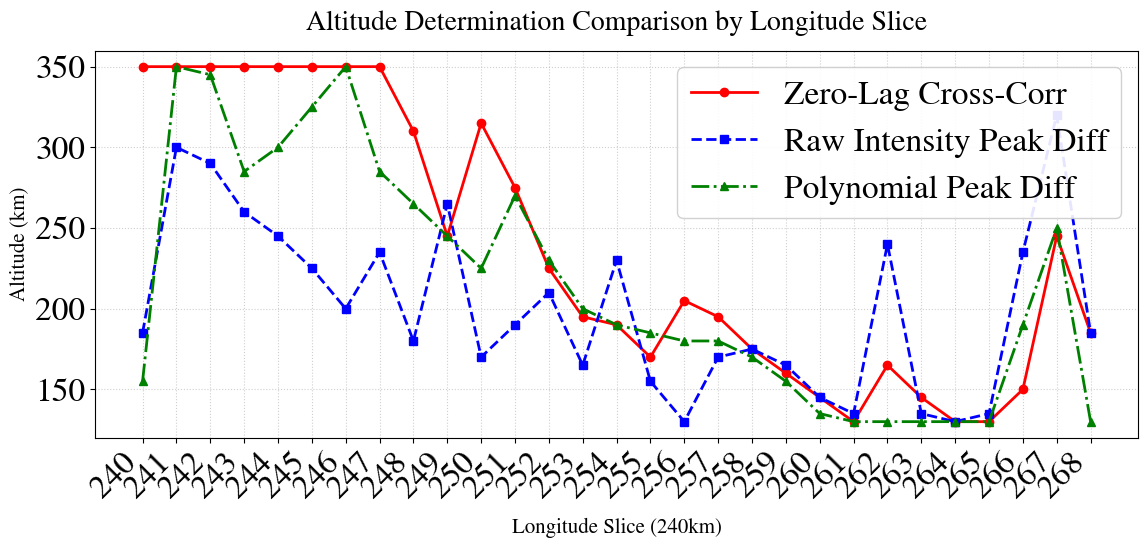

In [45]:
# Create x-axis string labels in the format "lon_240"
x_labels = [f"{int(lon)}" for lon in global_lon_arr]

plt.figure(figsize=(12, 6))

# Plot all 3 metrics on a single axis
plt.plot(x_labels, best_alt_zero_lag, marker='o', color='red', linewidth=2, label='Zero-Lag Cross-Corr')
plt.plot(x_labels, best_alt_raw_peak, marker='s', color='blue', linewidth=2, linestyle='--', label='Raw Intensity Peak Diff')
plt.plot(x_labels, best_alt_poly_peak, marker='^', color='green', linewidth=2, linestyle='-.', label='Polynomial Peak Diff')

# Labels and Styling
plt.xlabel('Longitude Slice (240km)', fontsize=15, labelpad=10)
plt.ylabel('Altitude (km)', fontsize=15)
plt.title('Altitude Determination Comparison by Longitude Slice', fontsize=20, pad=15)

plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for clean spacing
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)

# Adjust y-axis limits with padding around the projection bounds
plt.ylim(np.nanmin(h_target_arr)/1000.0 - 10, np.nanmax(h_target_arr)/1000.0 + 10)

plt.tight_layout()
plt.show()